# Leaf Density and LMA Model
## Douglas fir (PSME) and 9 Conifers
### Written By: Ella Keefer and Matt Jolly, USFS, Missoula Fire Sciences Laboratory
#### Date: 15 Dec 2025
### Revision History: 
#### Rev 1: 24 Apr 2026 (Response to paper reviewer comments and added analysis)
#### Rev 2: 28 Apr 2026 (Revised data pre-processing section)
#### Rev 3: 5 May 2026 (Adding final figures, preparing notebook for publication)

In [20]:
import math
import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.lines as mlines
from matplotlib.patches import Patch

from itertools import product

import statsmodels.formula.api as smf
from statsmodels.formula.api import ols
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.api import het_breuschpagan, normal_ad
from statsmodels.stats.stattools import durbin_watson
from statsmodels.graphics.gofplots import qqplot
from statsmodels.stats.outliers_influence import variance_inflation_factor
from pathlib import Path
from scipy import stats
from scipy.stats import pearsonr

from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import KFold
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Helper functions to calculate the mean and standard deviation by species and foliage age class
def MeanVal(df,species,NewOld,val):
    dftemp = df[df['species'] == species]
    dftemp = dftemp[dftemp['foliage'] == NewOld]
    return dftemp[val].mean()

In [3]:
col1 = '#d7191c'
col2 = '#fdae61'
col3 = '#ffffbf'
col4 = '#abdda4'
col5 = '#2b83ba'

## Data Preparation

### Read in the Doug fir chemistry and moisture data

In [4]:
# Read the PSME chemistry file
sheet = "Sheet1"
fn = "Data/PSME_macros 2.xlsx"
df_psme = pd.read_excel(fn, sheet_name=sheet)
df_psme['sample_dates'] = pd.to_datetime(df_psme['sample_dates'])   # Convert text dates to datetime64
df_psme = df_psme[df_psme.sample_dates >= '2021-01-01'].copy()   # Filter for PSME data 2021 and on
df_psme['nsc'] = (df_psme['percent_starch'] + df_psme['total_sugars'])

# Read the PSME moisture file
df_psme_rwc = pd.read_csv('Data/PSME_moisture 5.csv')
df_psme_rwc['SampleDate'] = pd.to_datetime(df_psme_rwc['SampleDate'])
df_psme_rwc = df_psme_rwc.rename(columns={"SampleDate":"sample_dates","NewOld":"foliage"})
df_psme_rwc['SAV_m'] = df_psme_rwc['SA_all_m']/df_psme_rwc['Vol_F_m']

#### Merge the two Doug fir datasets and filter out the oversaturated RWC values (< 75%)

In [5]:
df_psme['species'] = "PSEMEN"
df_psme_rwc['species'] = "PSEMEN"
df_psme_rwc_filtered = df_psme_rwc[df_psme_rwc['RWC'] >= 75]

# Calculate the sample period means for all variables by foliage age class
myVars = ['RWC','SAV_m','LMA_kg_m','k','LFMC','DryWt','Safresh','VWM']
df_rwc_unique = df_psme_rwc_filtered.groupby(['sample_dates', 'foliage'], as_index=False)[myVars].mean()

# Append all the sample period means by foliage age class
df_psme_merge = df_psme.merge(df_rwc_unique, on=['sample_dates', 'foliage'], how='left')
df_psme_merge['Density'] = df_psme_merge['LMA_kg_m'] * df_psme_merge['SAV_m']

#### Calculate Douglas fir mean values for LMA, SAV, K, DryWt and Density by species and foliage age class

In [6]:
df_psme_merge['mLMA']= df_psme_merge.apply(lambda row: MeanVal(df_psme_merge,row['species'],row['foliage'],'LMA_kg_m'),axis=1)
df_psme_merge['mSAV']= df_psme_merge.apply(lambda row: MeanVal(df_psme_merge,row['species'],row['foliage'], 'SAV_m'),axis=1)
df_psme_merge['mkappa']= df_psme_merge.apply(lambda row: MeanVal(df_psme_merge,row['species'],row['foliage'],'k'),axis=1)
df_psme_merge['mDryWt']= df_psme_merge.apply(lambda row: MeanVal(df_psme_merge,row['species'],row['foliage'],'DryWt'),axis=1)
df_psme_merge['mDensity']= df_psme_merge.apply(lambda row: MeanVal(df_psme_merge,row['species'],row['foliage'],'Density'),axis=1)

# Calculate the macro fractions for all components (scale from 0->100 to 0->1)
df_psme_merge['nsc'] = (df_psme_merge['nsc']/100.)
df_psme_merge['CF%'] = (df_psme_merge['CF%']/100.)
df_psme_merge['NDF%'] = (df_psme_merge['NDF%']/100.)

#### Extract the data needed for the regressions

In [7]:
df_psme_all = df_psme_merge[['foliage','species','sample_dates','nsc','CF%','NDF%','LMA_kg_m','DryWt','mLMA', 'RWC', 'mSAV', 'mkappa', 'LFMC', 'Safresh','mDryWt','Density','mDensity','SAV_m','k', 'VWM']].copy()

In [8]:
df_psme_all_sub = df_psme_all[['species','sample_dates','foliage','nsc','CF%','NDF%','LMA_kg_m','DryWt','Density','mSAV','SAV_m','LFMC','RWC','mkappa','k', 'VWM']].dropna()
df_psme_all_sub = df_psme_all_sub.rename(columns= {"CF%":"cf","NDF%":"ndf"})
df_psme_all_new = df_psme_all_sub[df_psme_all_sub.foliage == "New"].copy()
df_psme_all_old = df_psme_all_sub[df_psme_all_sub.foliage == "Old"].copy()

df_psme_all['doy'] = pd.to_datetime(df_psme_all['sample_dates'])
df_psme_all['doy'] = df_psme_all['doy'].dt.dayofyear
df_psme_all['Year'] = df_psme_all['sample_dates'].dt.year
df_2022 = df_psme_all[df_psme_all['Year'] == 2022].copy()
df_2022['nsc'] = (df_2022['nsc'] * 100.)
df_2022['CF%'] = (df_2022['CF%'] * 100.)
df_2022['NDF%'] = (df_2022['NDF%'] * 100.)

### Read in the Conifer chemistry and moisture data

In [9]:
variables = ["LMA_kg_m", "Density", "nsc", "CF%", "NDF%", "LFMC", "SAV_m", "k", "RWC"]

df_con = pd.read_excel('Data/conifer_macros 2.xlsx')
df_con['nsc'] = df_con['starch'] + df_con['totalsugar']

# Read the all conifers moisture and physical properties data
df_con_rwc = pd.read_csv('Data/conifer_moisture 3.csv')
df_con_rwc = df_con_rwc.rename(columns={"Species":"species","Site":"site","Foliage":"foliage"})

df_con = df_con.rename(columns={"Species":"species","Site":"site","Foliage":"foliage"})

#### Merge the two Conifer datasets and filter out the oversaturated RWC values (< 75%)

In [10]:
df_con['sample_dates'] = pd.to_datetime(df_con['SampleDate'])
df_con_rwc['sample_dates'] = pd.to_datetime(df_con_rwc['SampleDate'])
df_con_rwc_filtered = df_con_rwc[df_con_rwc['RWC'] >= 75]
df_con_rwc_unique = df_con_rwc_filtered.groupby(['species', 'site', 'sample_dates', 'foliage'], as_index=False)[myVars].mean()
df_con_merge = df_con.merge(df_con_rwc_unique, on=['species', 'site', 'sample_dates', 'foliage'], how='left')
df_con_merge['Density'] = df_con_merge['LMA_kg_m'] * df_con_merge['SAV_m']

#### Calculate all Conifer mean values for LMA, SAV, K, DryWt and Density by species and foliage age class

In [11]:
df_con_merge['mLMA'] = df_con_merge.apply(lambda row: MeanVal(df_con_rwc_filtered ,row['species'],row['foliage'],'LMA_kg_m'),axis=1)
df_con_merge['mkappa'] = df_con_merge.apply(lambda row: MeanVal(df_con_rwc_filtered ,row['species'],row['foliage'],'k'),axis=1)
df_con_merge['mSAV'] = df_con_merge.apply(lambda row: MeanVal(df_con_rwc_filtered ,row['species'],row['foliage'],'SAV_m'),axis=1)
df_con_merge['mDensity'] = df_con_merge.apply(lambda row: MeanVal(df_con_merge ,row['species'],row['foliage'],'Density'),axis=1)

# Calculate the macro fractions for all components (scale from 0->100 to 0->1)
df_con_merge['nsc'] = df_con_merge['nsc'] / 100.
df_con_merge['CF%'] = df_con_merge['CF%'] / 100.
df_con_merge['NDF%'] = df_con_merge['NDF%'] / 100.
df_con_merge = df_con_merge.rename(columns={'NDF%':'ndf','CF%':'cf'})

#### Extract the data needed for the regressions

In [12]:
df_con_new = df_con_merge[df_con_merge.foliage == "New"]
df_con_old = df_con_merge[df_con_merge.foliage == "Old"]
df_con_new = df_con_new[['sample_dates','species','foliage','nsc','cf','ndf','Density','SAV_m','mSAV','LMA_kg_m','mkappa','LFMC','RWC','k', 'VWM']].dropna()
df_con_old = df_con_old[['sample_dates','species','foliage','nsc','cf','ndf','Density','SAV_m','mSAV','LMA_kg_m','mkappa','LFMC','RWC','k', 'VWM']].dropna()

#### Merge the Douglas fir and Conifer datasets

In [13]:
df_con_new = pd.concat([df_con_new,df_psme_all_new])
df_con_old = pd.concat([df_con_old,df_psme_all_old])
df_con_concat = pd.concat([df_con_new,df_con_old])

In [14]:
# There are possibly a few duplicated rows in the two datasets.....

with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(df_con_concat[['sample_dates', 'species','foliage']].value_counts())

#df_con_all[(df_con_all['LFMC'] > 200) & (df_con_all['LFMC'] < 300) & (df_con_all['species'] == "PSEMEN")]

sample_dates  species  foliage
2022-06-30    PSEMEN   New        2
2022-09-20    PSEMEN   Old        2
2022-08-25    PSEMEN   Old        2
2021-04-21    PSEMEN   Old        1
2021-04-30    PSEMEN   Old        1
2021-05-05    PSEMEN   Old        1
2021-05-10    PSEMEN   Old        1
2021-05-14    PSEMEN   Old        1
2021-05-19    PSEMEN   Old        1
2021-04-06    PSEMEN   Old        1
2021-04-01    PSEMEN   Old        1
2021-05-27    PSEMEN   Old        1
2021-06-04    PSEMEN   Old        1
2021-06-16    PSEMEN   New        1
2021-06-09    PSEMEN   Old        1
2021-06-22    PSEMEN   New        1
                       Old        1
2022-03-30    PSEMEN   Old        1
2021-06-16    PSEMEN   Old        1
2022-05-04    PSEMEN   Old        1
2022-05-11    PSEMEN   Old        1
2022-05-18    PSEMEN   Old        1
2022-05-26    PSEMEN   Old        1
2022-06-01    PSEMEN   Old        1
2022-06-08    PSEMEN   Old        1
2022-06-15    ABIGRA   New        1
2022-04-27    PSEMEN   Old       

In [15]:
df_2022_rs = df_2022.set_index('sample_dates')
df_psme_merge_rs = df_psme_merge.set_index('sample_dates')

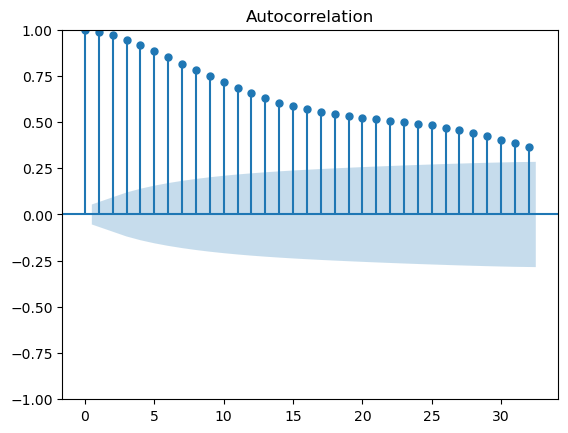

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

# 1. Resample to a regular frequency (e.g., Daily)
df_regular = df_psme_merge_rs.resample('D').LMA_kg_m.mean()

# 2. Fill gaps (Linear interpolation is often better for ACF than filling with 0)
df_filled = df_regular.interpolate(method='linear')

# 3. Plot the ACF
plot_acf(df_filled.dropna())
plt.show()

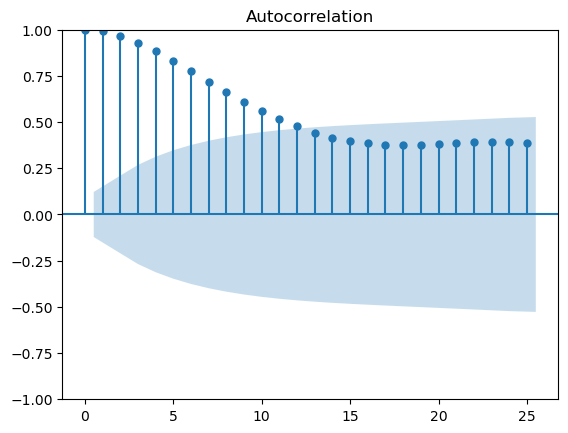

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

# 1. Resample to a regular frequency (e.g., Daily)
df_regular = df_2022_rs.resample('D').LMA_kg_m.mean()

# 2. Fill gaps (Linear interpolation is often better for ACF than filling with 0)
df_filled = df_regular.interpolate(method='linear')

# 3. Plot the ACF
plot_acf(df_filled.dropna())
plt.show()

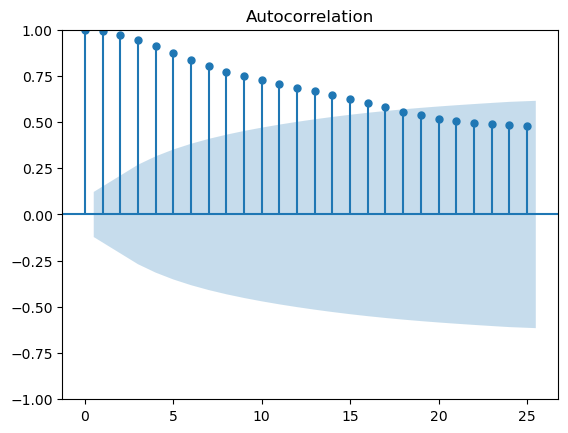

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

# 1. Resample to a regular frequency (e.g., Daily)
df_regular = df_2022_rs.resample('D').Density.mean()

# 2. Fill gaps (Linear interpolation is often better for ACF than filling with 0)
df_filled = df_regular.interpolate(method='linear')

# 3. Plot the ACF
plot_acf(df_filled.dropna())
plt.show()

In [23]:
path = Path("Figures/")
path.mkdir(parents=True, exist_ok=True)

# Exploratory Analysis Density and LMA

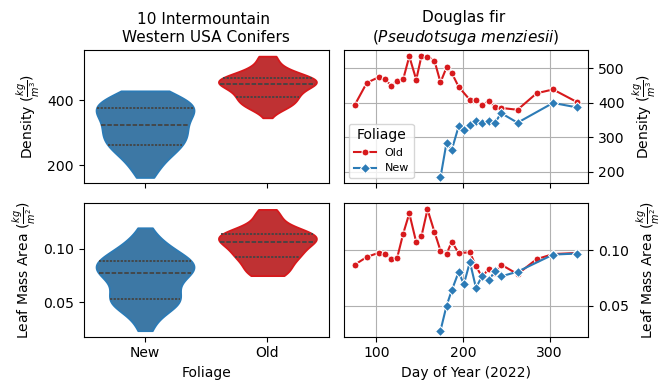

In [24]:
palette_violin = {"New": "#2c7bb6", "Old": "#d7191c"}
palette_line = {'New': '#2c7bb6', 'Old': '#d7191c'}
markers = {'New': 'D', 'Old': 'o'}

# Convert fractions → percent for violin plots
df_plot = df_con_concat[df_con_concat["foliage"].isin(["New", "Old"])].copy()
fraction_vars = ["nsc", "cf", "ndf"]
for col in fraction_vars:
    df_plot[col + "_pct"] = df_plot[col] * 100

violin_vars = [ 
    ("Density", "Density ($\\frac{kg}{m^3}$)"),
    ("LMA_kg_m", "Leaf Mass Area ($\\frac{kg}{m^2}$)")
]

line_vars = [
    ("Density", "Density ($\\frac{kg}{m^3}$)"),
    ('LMA_kg_m', "Leaf Mass Area ($\\frac{kg}{m^2}$)")
]

# Filter 2022 data for time series
df_2022_old = df_2022[df_2022['foliage'] == 'Old']
df_2022_new = df_2022[df_2022['foliage'] == 'New']

#  CREATE COMBINED FIGURE
fig, axes = plt.subplots(
    2, 2, figsize=(7, 4),
    sharex='col'
)

#  LEFT COLUMN: VIOLIN PLOTS
for i, (col, label) in enumerate(violin_vars):

    ax = axes[i, 0]

    sns.violinplot(
        data=df_plot,
        x="foliage",
        y=col,
        hue="foliage",
        palette=palette_violin,
        fill=True,
        alpha=0.5,
        linewidth=1.3,
        legend=False,
        ax=ax,
        cut=0,
        inner="quartile"
    )

    foliage_vals = df_plot["foliage"].unique()
    for j, patch in enumerate(ax.collections):
        hue_val = foliage_vals[j % len(foliage_vals)]
        patch.set_edgecolor(palette_violin[hue_val])
        patch.set_alpha(1)

    ax.set_ylabel(label, fontsize=10)
    ax.yaxis.set_label_position("left")
    ax.tick_params(axis="y", labelright=False, labelleft=True)

    if i < 1:
        ax.set_xlabel("")
        ax.tick_params(axis="x", labelbottom=False)
    else:
        ax.set_xlabel("Foliage")

axes[0, 0].set_title("10 Intermountain \nWestern USA Conifers", fontsize=11)

#  RIGHT COLUMN: TIME SERIES
for i, (var, ylab) in enumerate(line_vars):

    ax = axes[i, 1]

    sns.lineplot(
        data=df_2022,
        x='doy', y=var,
        hue='foliage', style='foliage',
        markers=markers, dashes=False,
        palette=palette_line, ax=ax, markersize=5
    )

    ax.set_ylabel(ylab)
    ax.grid(True)

    ax.yaxis.set_label_position("right")
    ax.yaxis.tick_right()

    if i < 1:
        ax.set_xlabel("")
        ax.tick_params(axis='x', labelbottom=False)
    else:
        ax.set_xlabel("Day of Year (2022)")

    ax.legend_.remove()

handles, labels = axes[0, 1].get_legend_handles_labels()
axes[0, 1].legend(handles, labels, title='Foliage',
                  loc='lower left', fontsize=8, frameon=True)

axes[0, 1].set_title("Douglas fir \n($\\mathit{Pseudotsuga}$ $\\mathit{menziesii}$)", fontsize=11)

plt.tight_layout()
plt.show()

fig.savefig("Figures/combined_violin_timeseries_lma.png", bbox_inches="tight")

In [ ]:
palette_violin = {"New": "#2c7bb6", "Old": "#d7191c"}
palette_line = {'New': '#2c7bb6', 'Old': '#d7191c'}
markers = {'New': 'D', 'Old': 'o'}

# Convert fractions → percent for violin plots
df_plot = df_con_concat[df_con_concat["foliage"].isin(["New", "Old"])].copy()
fraction_vars = ["nsc", "cf", "ndf"]
for col in fraction_vars:
    df_plot[col + "_pct"] = df_plot[col] * 100

violin_vars = [
    ("nsc_pct", "Non-Structural Carb %"),
    ("cf_pct", "Crude Fat %"),
    ("ndf_pct", "Neutral Det Fiber %")
]

line_vars = [
    ('nsc', "Non-Structural Carb %"),
    ('CF%', "Crude Fat %"),
    ('NDF%', "Neutral Det Fiber %"),
]

# Filter 2022 data for time series
df_2022_old = df_2022[df_2022['foliage'] == 'Old']
df_2022_new = df_2022[df_2022['foliage'] == 'New']

#  CREATE COMBINED FIGURE
fig, axes = plt.subplots(
    3, 2, figsize=(6.5, 5.5),
    sharex='col'
)

#  LEFT COLUMN: VIOLIN PLOTS
for i, (col, label) in enumerate(violin_vars):

    ax = axes[i, 0]

    sns.violinplot(
        data=df_plot,
        x="foliage",
        y=col,
        hue="foliage",
        palette=palette_violin,
        fill=True,
        alpha=0.5,
        linewidth=1.3,
        legend=False,
        ax=ax,
        cut=0,
        inner="quartile"
    )

    # Style violins
    foliage_vals = df_plot["foliage"].unique()
    for j, patch in enumerate(ax.collections):
        hue_val = foliage_vals[j % len(foliage_vals)]
        patch.set_edgecolor(palette_violin[hue_val])
        patch.set_alpha(1)

    # Axis labels
    ax.set_ylabel(label, fontsize=10)
    ax.yaxis.set_label_position("left")
    ax.tick_params(axis="y", labelright=False, labelleft=True)

    if i < 2:
        ax.set_xlabel("")
        ax.tick_params(axis="x", labelbottom=False)
    else:
        ax.set_xlabel("Foliage")

# Column title
axes[0, 0].set_title("10 Intermountain \nWestern USA Conifers", fontsize=11)

#  RIGHT COLUMN: TIME SERIES
for i, (var, ylab) in enumerate(line_vars):

    ax = axes[i, 1]

    sns.lineplot(
        data=df_2022,
        x='doy', y=var,
        hue='foliage', style='foliage',
        markers=markers, dashes=False,
        palette=palette_line, ax=ax, markersize=5
    )

    ax.set_ylabel(ylab)
    ax.grid(True)

    ax.yaxis.set_label_position("right")
    ax.yaxis.tick_right()

    if i < 2:
        ax.set_xlabel("")
        ax.tick_params(axis='x', labelbottom=False)
    else:
        ax.set_xlabel("Day of Year (2022)")

    ax.legend_.remove()

# Legend for right column
handles, labels = axes[0, 1].get_legend_handles_labels()
axes[0, 1].legend(handles, labels, title='Foliage',
                  loc='upper right', fontsize=8, frameon=True)

# Column title
axes[0, 1].set_title("Douglas fir \n($\\mathit{Pseudotsuga}$ $\\mathit{menziesii}$)", fontsize=11)

plt.tight_layout()
plt.show()

fig.savefig("Figures/combined_violin_timeseries.png", bbox_inches="tight")

In [25]:
df_plot = df_con_concat[df_con_concat["foliage"].isin(["New", "Old"])].copy()
fraction_vars = ["nsc", "cf", "ndf"]
for col in fraction_vars:
    df_plot[col + "_pct"] = df_plot[col] * 100
    
variables = ["LMA_kg_m", "Density", "nsc", "nsc_pct", "cf", "cf_pct", "ndf", "ndf_pct"]

for col in variables:
    print(f"\n=== {col} ===")
    mystats = df_plot.groupby("foliage")[col].agg(
        Q1=lambda x: x.quantile(0.25),
        Median="median",
        Q3=lambda x: x.quantile(0.75),
        Mean="mean",
        Std="std"
    )
    print(mystats)




=== LMA_kg_m ===
               Q1    Median        Q3      Mean       Std
foliage                                                  
New      0.053389  0.076990  0.088437  0.072955  0.022242
Old      0.092236  0.105955  0.113173  0.103550  0.015701

=== Density ===
                 Q1      Median          Q3        Mean        Std
foliage                                                           
New      262.283862  325.413513  376.818029  319.602262  69.830108
Old      410.585778  449.066610  468.917525  444.610766  43.059699

=== nsc ===
               Q1    Median        Q3      Mean       Std
foliage                                                  
New      0.041032  0.061879  0.088707  0.069296  0.037355
Old      0.056282  0.100610  0.200035  0.123440  0.074999

=== nsc_pct ===
               Q1     Median         Q3       Mean       Std
foliage                                                     
New      4.103199   6.187885   8.870700   6.929560  3.735537
Old      5.628213  1

### Create Table 4 from manuscript

In [26]:
df_plot.groupby([df_plot.species,df_plot.foliage])[['LMA_kg_m','Density','SAV_m','nsc_pct','cf_pct','ndf_pct']].mean().round(2)

LMA_kg_m  Density    SAV_m  nsc_pct  cf_pct  ndf_pct
species foliage                                                      
ABIGRA  New          0.06   276.07  4457.91     4.56    4.49    33.08
        Old          0.09   399.07  4259.48     5.62    5.42    37.60
ABILAS  New          0.08   328.31  4249.73     5.04    6.91    37.05
        Old          0.11   423.94  3967.03     7.45    7.89    35.12
LAROCC  New          0.05   268.32  5144.82     7.36    6.70    34.95
PICENG  New          0.09   314.72  3447.29    12.36    3.97    40.58
        Old          0.13   471.54  3760.69    17.57    3.00    41.15
PINALB  New          0.09   362.12  4290.45     4.29    6.60    39.62
        Old          0.11   439.70  4031.01     6.07    8.41    37.08
PINCON  New          0.08   356.94  4449.59     5.94    4.52    42.27
        Old          0.10   457.87  4672.73     8.94    3.57    42.87
PINMON  New          0.07   319.57  4421.96     4.22    3.99    41.65
        Old          0.08   408.14  5399.69     5.32    5.18    41.20
PINPON  New          0.09   370.82  4149.72     7.02    6.25    43.40
        Old          0.12   457.84  3932.63     5.32    7.28    39.87
PSEMEN  New          0.07   324.13  4890.92     9.01    2.40    33.08
        Old          0.10   453.55  4402.77    15.58    2.97    30.07
TSUHET  New          0.06   273.05  5371.61     4.05    6.43    33.02
        Old          0.08   396.83  4854.59     5.62    6.68    33.27

### Create Table 5 from manuscript

#### Douglas fir minimum, maximum and % variability by species for new and foliage

In [27]:
df_psme_all.groupby(['species', 'foliage'], as_index=False)['Density'].agg(
    min='min',
    max='max',
    pct_variability=lambda x: (x.max() - x.min()) / x.min() * 100
)

,species,foliage,min,max,pct_variability
0,PSEMEN,New,183.188144,399.649970,118.163666
1,PSEMEN,Old,379.715916,535.376114,40.993856


In [28]:
df_psme_all.groupby(['species', 'foliage'], as_index=False)['LMA_kg_m'].agg(
    min='min',
    max='max',
    pct_variability=lambda x: (x.max() - x.min()) / x.min() * 100
)

,species,foliage,min,max,pct_variability
0,PSEMEN,New,0.027567,0.096864,251.379991
1,PSEMEN,Old,0.076033,0.136468,79.485200


#### Douglas fir minimum, maximum and % variability by species for all foliage

In [29]:
df_psme_all.groupby(['species'], as_index=False)['Density'].agg(
    min='min',
    max='max',
    pct_variability=lambda x: (x.max() - x.min()) / x.min() * 100
)

,species,min,max,pct_variability
0,PSEMEN,183.188144,535.376114,192.254784


In [30]:
df_psme_all.groupby(['species'], as_index=False)['LMA_kg_m'].agg(
    min='min',
    max='max',
    pct_variability=lambda x: (x.max() - x.min()) / x.min() * 100
)

,species,min,max,pct_variability
0,PSEMEN,0.027567,0.136468,395.042748


## Build density model and predict LMA and LFMC

### t-Test to compare new and old values for Density, LMA, NSC, NDF and CF

In [31]:
stats

<module 'scipy.stats' from 'C:\\Users\\mjolly\\.conda\\envs\\gdal\\Lib\\site-packages\\scipy\\stats\\__init__.py'>

In [32]:
# t-Tests comparing New and Old Density
stats.ttest_ind(df_con_new.Density.values, df_con_old.Density.values)

TtestResult(statistic=np.float64(-11.52430513048944), pvalue=np.float64(1.6024611778845783e-20), df=np.float64(108.0))

In [33]:
# t-Tests comparing New and Old LMA
stats.ttest_ind(df_con_new.LMA_kg_m.values, df_con_old.LMA_kg_m.values)

TtestResult(statistic=np.float64(-8.442828300967058), pvalue=np.float64(1.5584639913389232e-13), df=np.float64(108.0))

In [34]:
# t-Tests comparing New and Old NSC
stats.ttest_ind(df_con_new.nsc.values, df_con_old.nsc.values)

TtestResult(statistic=np.float64(-4.612008933159833), pvalue=np.float64(1.1010516211323254e-05), df=np.float64(108.0))

In [35]:
# t-Tests comparing New and Old NDF
stats.ttest_ind(df_con_new.ndf.values, df_con_old.ndf.values)

TtestResult(statistic=np.float64(3.0793362430901676), pvalue=np.float64(0.0026309417354750384), df=np.float64(108.0))

In [36]:
# t-Tests comparing New and Old CF
stats.ttest_ind(df_con_new.cf.values, df_con_old.cf.values)

TtestResult(statistic=np.float64(0.9224547308828481), pvalue=np.float64(0.35834762082208027), df=np.float64(108.0))

### Two-way ANOVA for Species and Foliage Age Class for LMA and Density

In [37]:
# Fit the model with an interaction term (Factor1 * Factor2)
# The 'C()' notation explicitly treats variables as categorical
model = ols('Density ~ C(species) + C(foliage) + C(species):C(foliage)', data=df_con_merge).fit()

# Generate the ANOVA table (Type II is recommended for balanced/unbalanced designs)
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

                             sum_sq    df           F        PR(>F)
C(species)             1.095532e+05  10.0    3.589298  2.193218e-03
C(foliage)             1.066646e+06   2.0  174.732914  2.942836e-18
C(species):C(foliage)  7.558152e+04  20.0    1.238141  2.700300e-01
Residual               1.587154e+05  52.0         NaN           NaN


In [38]:
# Fit the model with an interaction term (Factor1 * Factor2)
# The 'C()' notation explicitly treats variables as categorical
model = ols('LMA_kg_m ~ C(species) + C(foliage) + C(species):C(foliage)', data=df_con_merge).fit()

# Generate the ANOVA table (Type II is recommended for balanced/unbalanced designs)
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

                         sum_sq    df           F        PR(>F)
C(species)             0.006189  10.0    2.367330  2.966213e-02
C(foliage)             0.057784   2.0  110.515044  1.797763e-14
C(species):C(foliage)  0.013246  20.0    2.533423  5.261125e-03
Residual               0.013594  52.0         NaN           NaN


In [39]:
df_con_merge['LMA_kg_m'].quantile([0.05,0.95])

0.05    0.049236
0.95    0.118765
Name: LMA_kg_m, dtype: float64

### Regression Analysis

#### Assign a dummy variable for new and old foliage

In [40]:
df_con_new['NewOldDV'] = 1  # 1 for new and 0 for old
df_con_old['NewOldDV'] = 0  # 0 for old

In [41]:
df_con_all = pd.concat([df_con_new,df_con_old])

#### Combined model using dummy variable

In [42]:
model_con_all = smf.ols(formula='Density ~ nsc +  ndf + cf + NewOldDV - 1', data=df_con_all).fit(cov_type='hc3')

In [43]:
print(model_con_all.summary())

                                 OLS Regression Results                                
Dep. Variable:                Density   R-squared (uncentered):                   0.982
Model:                            OLS   Adj. R-squared (uncentered):              0.981
Method:                 Least Squares   F-statistic:                              2030.
Date:                Wed, 13 May 2026   Prob (F-statistic):                    3.68e-99
Time:                        13:13:57   Log-Likelihood:                         -594.63
No. Observations:                 110   AIC:                                      1197.
Df Residuals:                     106   BIC:                                      1208.
Df Model:                           4                                                  
Covariance Type:                  hc3                                                  
                 coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------

#### Separate new and old foliage models

In [44]:
model_con_new = smf.ols(formula='Density ~ nsc +  ndf + cf - 1', data=df_con_new).fit()
model_con_old = smf.ols(formula='Density ~ nsc +  ndf + cf - 1', data=df_con_old).fit()

In [45]:
print(model_con_new.summary())

                                 OLS Regression Results                                
Dep. Variable:                Density   R-squared (uncentered):                   0.972
Model:                            OLS   Adj. R-squared (uncentered):              0.971
Method:                 Least Squares   F-statistic:                              538.6
Date:                Wed, 13 May 2026   Prob (F-statistic):                    8.03e-36
Time:                        13:13:59   Log-Likelihood:                         -265.35
No. Observations:                  49   AIC:                                      536.7
Df Residuals:                      46   BIC:                                      542.4
Df Model:                           3                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [46]:
print(model_con_old.summary())

                                 OLS Regression Results                                
Dep. Variable:                Density   R-squared (uncentered):                   0.991
Model:                            OLS   Adj. R-squared (uncentered):              0.990
Method:                 Least Squares   F-statistic:                              2110.
Date:                Wed, 13 May 2026   Prob (F-statistic):                    3.71e-59
Time:                        13:13:59   Log-Likelihood:                         -315.36
No. Observations:                  61   AIC:                                      636.7
Df Residuals:                      58   BIC:                                      643.0
Df Model:                           3                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

#### Diagnostic statistics for all three density models

In [47]:
#Linearity: The relationship between predictors and the outcome is linear.
#Independence of Errors: Residuals are independent of each other.
#Homoscedasticity: The variance of the residuals is constant across all levels of the independent variables.
#Normality of Residuals: Residuals are normally distributed.
#No Multicollinearity (Optional but good to check): Independent variables are not highly correlated with each other.

In [48]:
def PlotResiduals(model,df,myLabel):
    
    # Get residuals and fitted values
    residuals = model.resid
    fitted_values = model.fittedvalues
    
    # A. Linearity
    # This is often checked by plotting residuals against fitted values or against each predictor.
    # If the relationship is linear, residuals should be randomly scattered around zero.
    
    f,axs = plt.subplots(2,2,figsize=(12, 5))
    
    ax = axs[0,0]
    plt.suptitle(myLabel)
    sns.scatterplot(x=fitted_values, y=residuals,ax=ax)
    ax.axhline(0, color='red', linestyle='--')
    ax.set_title('Residuals vs. Fitted Values')
    ax.set_xlabel('Fitted Values')
    ax.set_ylabel('Residuals')
    
    ax = axs[0,1]
    sns.scatterplot(x=df.nsc, y=residuals,ax=ax)
    ax.axhline(0, color='red', linestyle='--')
    ax.set_title('Residuals vs.NSC')
    ax.set_xlabel('NSC')
    ax.set_ylabel('Residuals')
    
    
    ax = axs[1,0]
    sns.scatterplot(x=df.ndf, y=residuals,ax=ax)
    ax.axhline(0, color='red', linestyle='--')
    ax.set_title('Residuals vs. NDF')
    ax.set_xlabel('NDF')
    ax.set_ylabel('Residuals')
    
    ax = axs[1,1]
    sns.scatterplot(x=df.cf, y=residuals,ax=ax)
    ax.axhline(0, color='red', linestyle='--')
    ax.set_title('Residuals vs.CF')
    ax.set_xlabel('CF')
    ax.set_ylabel('Residuals')
    
    plt.tight_layout()


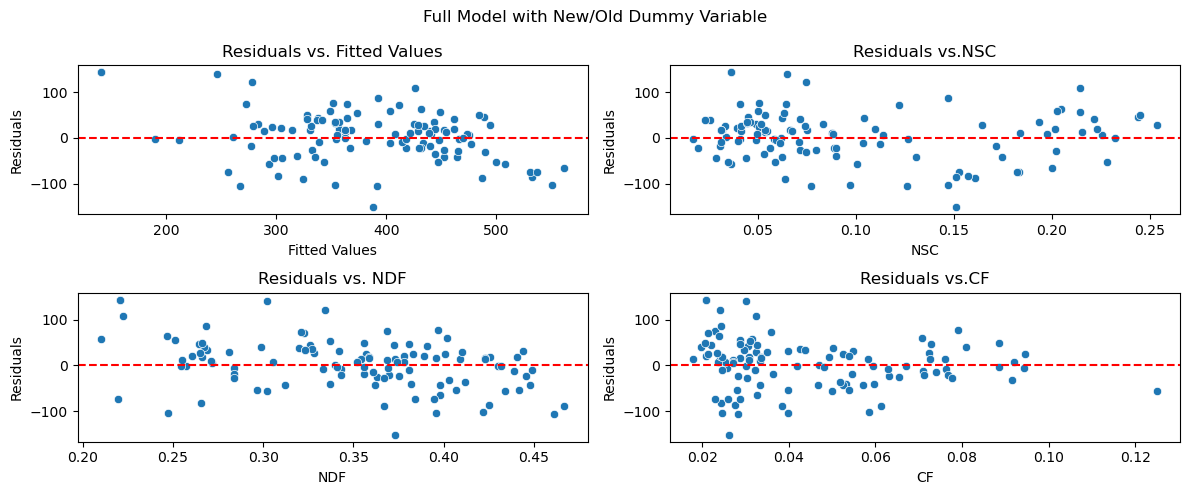

In [49]:
PlotResiduals(model_con_all,df_con_all,"Full Model with New/Old Dummy Variable")

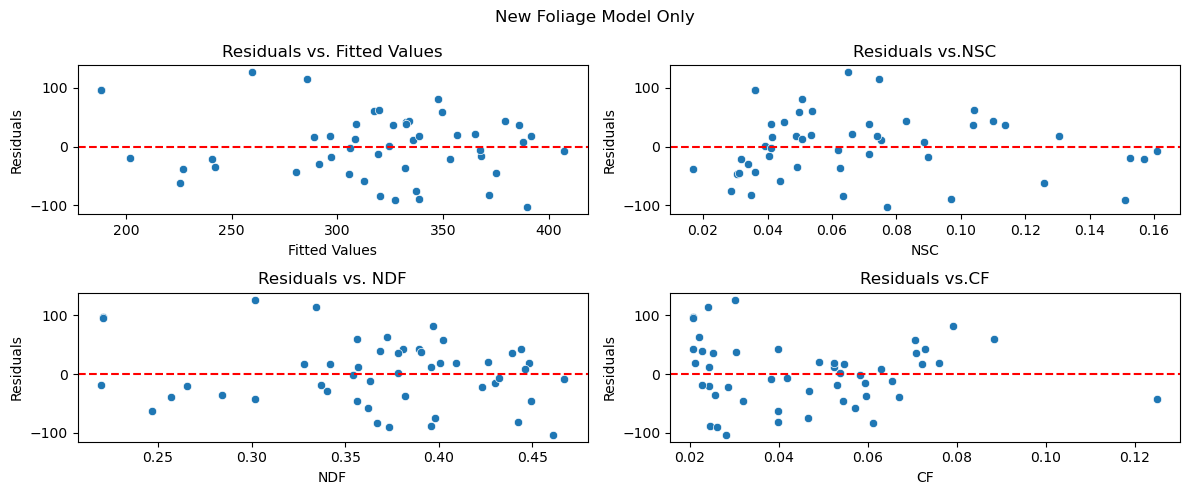

In [50]:
PlotResiduals(model_con_new,df_con_new,"New Foliage Model Only")

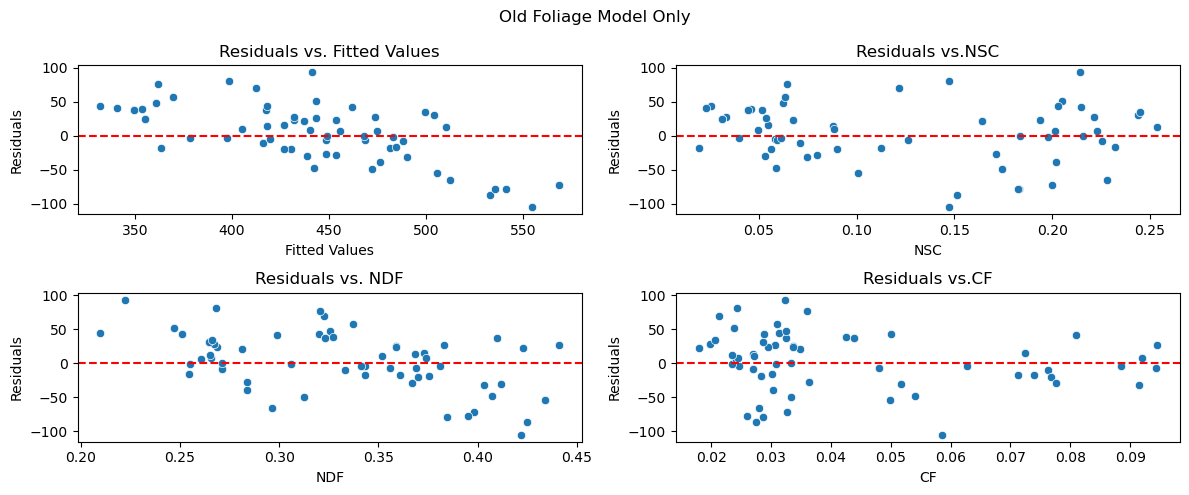

In [51]:
PlotResiduals(model_con_old,df_con_old,"Old Foliage Model Only")

In [52]:
def IndependenceOfErrors(model):
    residuals = model.resid
    # Durbin-Watson statistic
    # A value around 2 suggests no autocorrelation.
    # Values < 1 or > 3 often indicate issues.
    dw_statistic = durbin_watson(residuals)
    print(f"\nDurbin-Watson Statistic: {dw_statistic:.3f}")

In [53]:
IndependenceOfErrors(model_con_all)


Durbin-Watson Statistic: 1.335


In [54]:
IndependenceOfErrors(model_con_new)


Durbin-Watson Statistic: 1.385


In [55]:
IndependenceOfErrors(model_con_old)


Durbin-Watson Statistic: 1.441


In [56]:
def HomoscedasticityTest(model):
    residuals = model.resid
    fitted_values = model.fittedvalues

    # model_no_intercept.model.exog already gives us the design matrix *without* the intercept.
    bp_exog = model.model.exog
    
    # Now, add a constant to this exog for the Breusch-Pagan test
    # sm.add_constant will add a column of ones to your array/DataFrame.
    bp_exog_with_constant = sm.add_constant(bp_exog, prepend=True) # prepend=True adds it as the first column
    
    # 4. Perform Breusch-Pagan Test
    
    
    # Breusch-Pagan test for heteroscedasticity
    # Null Hypothesis (H0): Homoscedasticity exists (residuals have constant variance).
    # Alternative Hypothesis (Ha): Heteroscedasticity exists (residuals do not have constant variance).
    
    # The Breusch-Pagan test requires the independent variables used in the original model.
    bp_test = het_breuschpagan(residuals, bp_exog_with_constant)
    labels = ['LM Statistic', 'LM p-value', 'F-Statistic', 'F p-value']
    print(f"\nBreusch-Pagan Test:")
    for label, value in zip(labels, bp_test):
        print(f"  {label}: {value:.3f}")
    
    if bp_test[1] < 0.05:
        print("  Conclusion: We reject the null hypothesis, suggesting heteroscedasticity is present.")
    else:
        print("  Conclusion: We fail to reject the null hypothesis, suggesting homoscedasticity.")
    
    # Plot of residuals vs. fitted values (again, useful for visual check)
    #plt.figure(figsize=(8, 5))
    #sns.scatterplot(x=fitted_values, y=np.abs(residuals)) # Plotting absolute residuals can make the funnel shape clearer
    #lt.axhline(0, color='red', linestyle='--')
    #plt.title('Absolute Residuals vs. Fitted Values (Homoscedasticity Check)')
    #plt.xlabel('Fitted Values')
    #plt.ylabel('Absolute Residuals')
    #plt.show()

In [57]:
HomoscedasticityTest(model_con_all)


Breusch-Pagan Test:
  LM Statistic: 20.155
  LM p-value: 0.000
  F-Statistic: 5.889
  F p-value: 0.000
  Conclusion: We reject the null hypothesis, suggesting heteroscedasticity is present.


In [58]:
HomoscedasticityTest(model_con_new)


Breusch-Pagan Test:
  LM Statistic: 6.038
  LM p-value: 0.110
  F-Statistic: 2.108
  F p-value: 0.112
  Conclusion: We fail to reject the null hypothesis, suggesting homoscedasticity.


In [59]:
HomoscedasticityTest(model_con_old)


Breusch-Pagan Test:
  LM Statistic: 8.206
  LM p-value: 0.042
  F-Statistic: 2.953
  F p-value: 0.040
  Conclusion: We reject the null hypothesis, suggesting heteroscedasticity is present.


In [60]:
def TestForNormality(model,myTitle):
    residuals = model.resid
    fitted_values = model.fittedvalues
    # Anderson-Darling test for normality
    # Null Hypothesis (H0): The data comes from a normal distribution.
    # Alternative Hypothesis (Ha): The data does not come from a normal distribution.
    ad_test = normal_ad(residuals)
    print(f"\nAnderson-Darling Test for Normality:")
    print(f"  Statistic: {ad_test[0]:.3f}")
    print(f"  p-value: {ad_test[1]:.3f}")
    
    if ad_test[1] < 0.05:
        print("  Conclusion: We reject the null hypothesis, suggesting residuals are not normally distributed.")
    else:
        print("  Conclusion: We fail to reject the null hypothesis, suggesting residuals are normally distributed.")
    
    # QQ-Plot
    plt.figure(figsize=(10, 5))
    qqplot(residuals, line='s', ax=plt.subplot(1, 2, 1))
    plt.title('QQ-Plot of Residuals')
    
    # Histogram of Residuals
    plt.suptitle(myTitle)
    plt.subplot(1, 2, 2)
    sns.histplot(residuals, kde=True)
    plt.title('Histogram of Residuals')
    plt.xlabel('Residuals')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()


Anderson-Darling Test for Normality:
  Statistic: 0.745
  p-value: 0.051
  Conclusion: We fail to reject the null hypothesis, suggesting residuals are normally distributed.


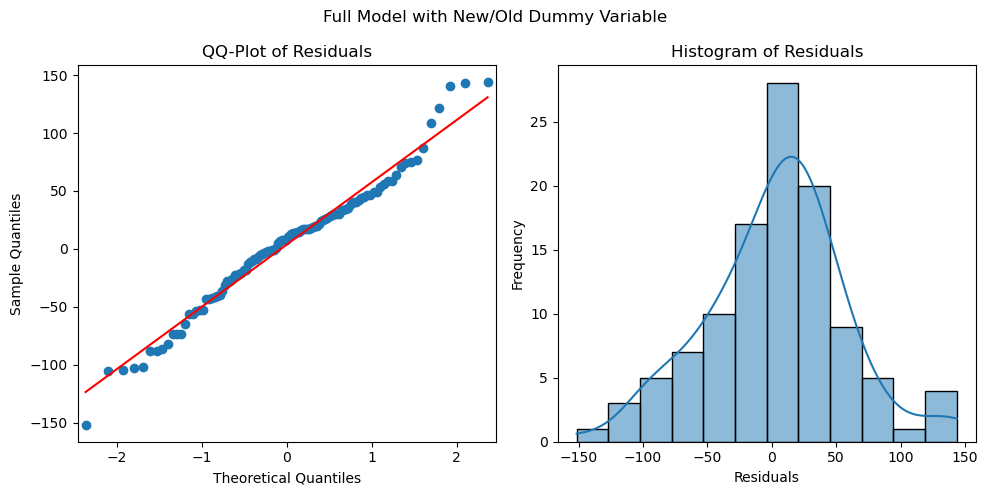

In [61]:
TestForNormality(model_con_all,"Full Model with New/Old Dummy Variable")


Anderson-Darling Test for Normality:
  Statistic: 0.179
  p-value: 0.913
  Conclusion: We fail to reject the null hypothesis, suggesting residuals are normally distributed.


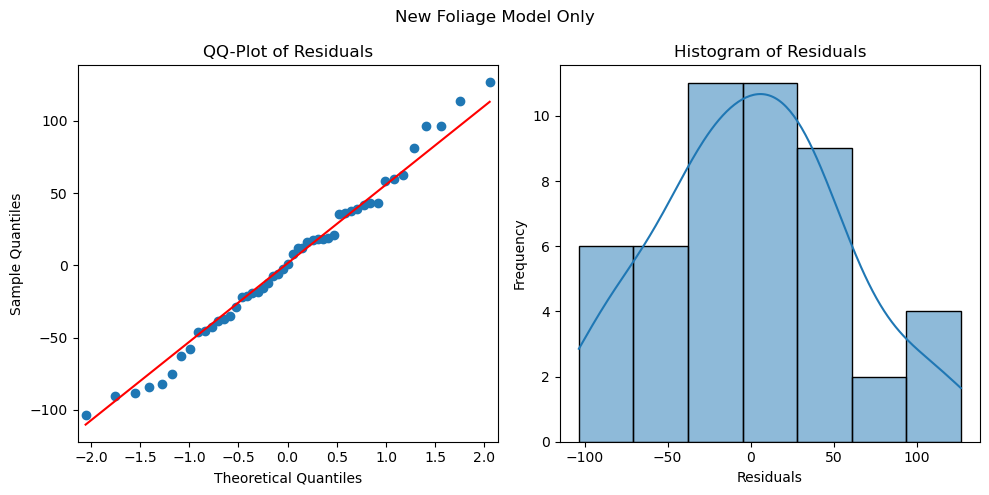

In [62]:
TestForNormality(model_con_new,"New Foliage Model Only")


Anderson-Darling Test for Normality:
  Statistic: 0.410
  p-value: 0.333
  Conclusion: We fail to reject the null hypothesis, suggesting residuals are normally distributed.


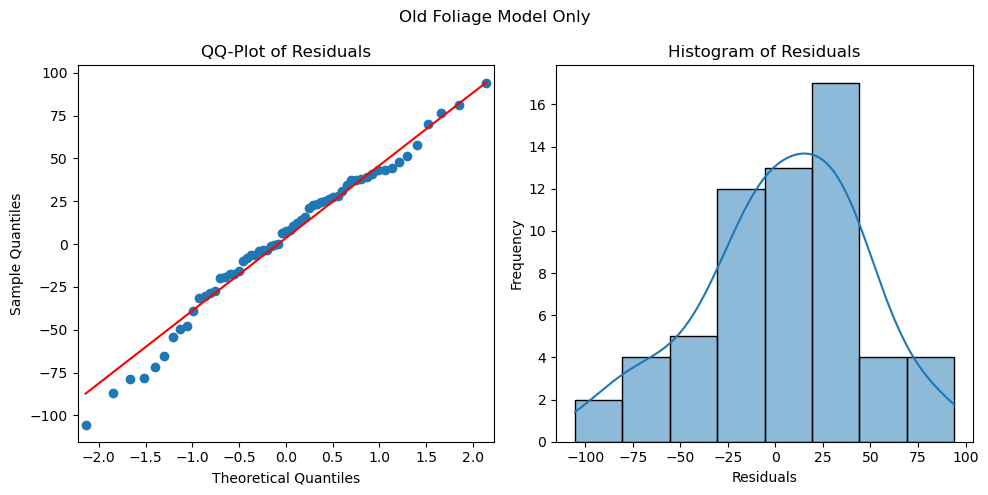

In [63]:
TestForNormality(model_con_old,"Old Foliage Model Only")

In [64]:
# Test for Multicolinearity

In [65]:
def TestForMulticolinearity(df,myVars=['nsc','ndf','cf']):
    # Calculate VIF for each independent variable
    # VIF > 5 or 10 is often considered problematic.
    exog = df[myVars]
    vif_data = pd.DataFrame()
    vif_data["Variable"] = exog.columns
    vif_data["VIF"] = [variance_inflation_factor(exog.values, i) for i in range(exog.shape[1])]
    
    print("\nVariance Inflation Factor (VIF):")
    print(vif_data)
    
    # Correlation matrix
    print("\nCorrelation Matrix of Independent Variables:")
    print(df[myVars].corr())

In [66]:
TestForMulticolinearity(df_con_all)


Variance Inflation Factor (VIF):
  Variable       VIF
0      nsc  2.634525
1      ndf  8.491363
2       cf  5.652350

Correlation Matrix of Independent Variables:
          nsc       ndf        cf
nsc  1.000000 -0.465169 -0.478749
ndf -0.465169  1.000000  0.249830
cf  -0.478749  0.249830  1.000000


In [67]:
TestForMulticolinearity(df_con_new)


Variance Inflation Factor (VIF):
  Variable        VIF
0      nsc   4.453151
1      ndf  10.798135
2       cf   5.508589

Correlation Matrix of Independent Variables:
          nsc       ndf        cf
nsc  1.000000  0.031166 -0.349869
ndf  0.031166  1.000000  0.093634
cf  -0.349869  0.093634  1.000000


In [68]:
TestForMulticolinearity(df_con_old)


Variance Inflation Factor (VIF):
  Variable       VIF
0      nsc  2.953251
1      ndf  9.837527
2       cf  6.132054

Correlation Matrix of Independent Variables:
          nsc       ndf        cf
nsc  1.000000 -0.627650 -0.575332
ndf -0.627650  1.000000  0.360957
cf  -0.575332  0.360957  1.000000


### 5-Fold Cross-Validation for all three density models

In [69]:
def KFoldCrossVal(df,nFolds=5,depVar='Density',indepVars=['nsc','ndf','cf','NewOldDV']):
    # 1. Prep the input data 
    y = df[depVar]
    X = df[indepVars]
    df = pd.DataFrame(X, columns=['nsc','ndf','cf','NewOldDV'])
    df['Density'] = y

    # 2. Set up KFold cross-validation
    n_splits = nFolds # For 5-fold cross-validation
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    # Lists to store results
    mae_scores = []
    corr_scores = []
    
    print(f"Performing {n_splits}-fold cross-validation...")
    
    # 3. Iterate through each fold
    for fold, (train_index, test_index) in enumerate(kf.split(X)):
        print(f"\n--- Fold {fold + 1}/{n_splits} ---")
    
        # 4. Split data into train and test sets for this fold
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
        df_train = pd.DataFrame(X_train, columns=['nsc','ndf','cf','NewOldDV'])
        df_train['Density'] = y_train
        df_test = pd.DataFrame(X_test, columns=['nsc','ndf','cf','NewOldDV'])
        df_test['Density'] = y_test
    
        # 5. Fit the model for this fold
        model = smf.ols(formula='Density ~ nsc +  ndf + cf + NewOldDV - 1', data=df_train)
        results = model.fit()
    
        # 6. Test the model fit against the held-out data
        y_pred = results.predict(X_test)
    
        # 7. Evaluate the model performance
        # Calc the correlation between measured and predicted
        fold_corr, fold_pval = stats.pearsonr(y_test,y_pred)
        # Calc the mean absolute error between measured and predicted
        fold_mae = mean_absolute_error(y_test, y_pred)
        
        # 8. Save the stats for this fold 
        mae_scores.append(fold_mae)
        corr_scores.append(fold_corr)
        
        print(f"Fold {fold + 1} - Mean Absoluate Error (MAE): {fold_mae:.4f}")
        print(f"Fold {fold + 1} - Corr (Pearsons) : {fold_corr:.4f}")
    
    # 7. Aggregate and display results
    print("\n--- Cross-validation Results ---")
    print(f"Average MAE: {np.mean(mae_scores):.4f} (+/- {np.std(mae_scores):.4f})")
    print(f"Average Corr: {np.mean(corr_scores):.4f} (+/- {np.std(corr_scores):.4f})")


In [70]:
KFoldCrossVal(df_con_all,nFolds=5,depVar='Density',indepVars=['nsc','ndf','cf','NewOldDV'])

Performing 5-fold cross-validation...

--- Fold 1/5 ---
Fold 1 - Mean Absoluate Error (MAE): 42.6232
Fold 1 - Corr (Pearsons) : 0.7988

--- Fold 2/5 ---
Fold 2 - Mean Absoluate Error (MAE): 47.4597
Fold 2 - Corr (Pearsons) : 0.8505

--- Fold 3/5 ---
Fold 3 - Mean Absoluate Error (MAE): 42.6123
Fold 3 - Corr (Pearsons) : 0.8327

--- Fold 4/5 ---
Fold 4 - Mean Absoluate Error (MAE): 40.5982
Fold 4 - Corr (Pearsons) : 0.7254

--- Fold 5/5 ---
Fold 5 - Mean Absoluate Error (MAE): 47.3212
Fold 5 - Corr (Pearsons) : 0.6803

--- Cross-validation Results ---
Average MAE: 44.1229 (+/- 2.7683)
Average Corr: 0.7775 (+/- 0.0648)


In [71]:
KFoldCrossVal(df_con_new,nFolds=5,depVar='Density',indepVars=['nsc','ndf','cf','NewOldDV'])

Performing 5-fold cross-validation...

--- Fold 1/5 ---
Fold 1 - Mean Absoluate Error (MAE): 51.4746
Fold 1 - Corr (Pearsons) : 0.6282

--- Fold 2/5 ---
Fold 2 - Mean Absoluate Error (MAE): 49.7754
Fold 2 - Corr (Pearsons) : 0.5415

--- Fold 3/5 ---
Fold 3 - Mean Absoluate Error (MAE): 39.0311
Fold 3 - Corr (Pearsons) : 0.8448

--- Fold 4/5 ---
Fold 4 - Mean Absoluate Error (MAE): 43.3296
Fold 4 - Corr (Pearsons) : 0.4535

--- Fold 5/5 ---
Fold 5 - Mean Absoluate Error (MAE): 71.5490
Fold 5 - Corr (Pearsons) : -0.0593

--- Cross-validation Results ---
Average MAE: 51.0319 (+/- 11.1899)
Average Corr: 0.4817 (+/- 0.3001)


In [72]:
KFoldCrossVal(df_con_old,nFolds=5,depVar='Density',indepVars=['nsc','ndf','cf','NewOldDV'])

Performing 5-fold cross-validation...

--- Fold 1/5 ---
Fold 1 - Mean Absoluate Error (MAE): 37.2653
Fold 1 - Corr (Pearsons) : 0.4591

--- Fold 2/5 ---
Fold 2 - Mean Absoluate Error (MAE): 27.0496
Fold 2 - Corr (Pearsons) : 0.7830

--- Fold 3/5 ---
Fold 3 - Mean Absoluate Error (MAE): 38.6077
Fold 3 - Corr (Pearsons) : 0.7244

--- Fold 4/5 ---
Fold 4 - Mean Absoluate Error (MAE): 38.1426
Fold 4 - Corr (Pearsons) : 0.7423

--- Fold 5/5 ---
Fold 5 - Mean Absoluate Error (MAE): 36.9794
Fold 5 - Corr (Pearsons) : 0.4561

--- Cross-validation Results ---
Average MAE: 35.6089 (+/- 4.3196)
Average Corr: 0.6330 (+/- 0.1445)


In [73]:
all_conf_pred_new = model_con_new.predict(df_con_new)
all_conf_pred_old = model_con_old.predict(df_con_old)
all_conf_pred = model_con_all.predict(df_con_all)

In [74]:
corr_all, p_all = stats.pearsonr(df_con_all.Density,all_conf_pred)
corr_new, p_new = stats.pearsonr(df_con_new.Density,all_conf_pred_new)
corr_old, p_old = stats.pearsonr(df_con_old.Density,all_conf_pred_old)

In [75]:
print(corr_all,p_all)

0.7930872516742239 5.365265045753043e-25


In [76]:
print(corr_new,p_new)

0.6314243739738578 1.1467179229321197e-06


In [77]:
print(corr_old,p_old)

0.6637424830601746 5.5323778679138154e-09


### Predictions and estimates using final combined model

In [78]:
# Predictions and estimates for the full data set
df_con_all['DensityHat'] = model_con_all.predict(df_con_all)
df_con_all['LMAHat'] = df_con_all['DensityHat'] / df_con_all['mSAV']
df_con_all['LFMC2025'] = df_con_all.RWC * df_con_all.mkappa /(df_con_all.LMAHat* df_con_all.mSAV)
df_con_all['LFMCvw'] = (df_con_all.VWM / df_con_all.DensityHat)* 100

In [79]:
# Predict Density for the individual models
df_con_new['DensityHat'] = model_con_new.predict(df_con_new)
df_con_old['DensityHat'] =  model_con_old.predict(df_con_old)

# Calculate LMA from predicted Density and species/foliage age class-mean SAV
df_con_old['LMAHat'] = df_con_old['DensityHat'] / df_con_old['mSAV']
df_con_new['LMAHat'] = df_con_new['DensityHat'] / df_con_new['mSAV']

# Calculate the LFMC from the mechanistic LFMC model 
df_con_new['LFMC2025'] = df_con_new.RWC * df_con_new.mkappa /(df_con_new.LMAHat* df_con_new.mSAV)
df_con_old['LFMC2025'] = df_con_old.RWC * df_con_old.mkappa /(df_con_old.LMAHat* df_con_old.mSAV)

# Calculate the LFMC using the predicted density and measured Volumetric Water Mass (VWM)
df_con_new['LFMCvw'] = (df_con_new.VWM / df_con_new.DensityHat)* 100
df_con_old['LFMCvw'] = (df_con_old.VWM / df_con_old.DensityHat)* 100

In [80]:
df_con_concat = pd.concat([df_con_new,df_con_old])

In [81]:
variables = ["LMA_kg_m", "Density", "nsc", "cf", "ndf", "LFMC", "SAV_m", "k", "RWC"]

df_con_concat[variables].count()

LMA_kg_m    110
Density     110
nsc         110
cf          110
ndf         110
LFMC        110
SAV_m       110
k           110
RWC         110
dtype: int64

## Plotting modeled density and predicted LMA

In [82]:
tab10 = cm.get_cmap("tab10")
species_colors = {
    "ABIGRA": tab10(1),   # orange
    "ABILAS": tab10(2),   # green
    "LAROCC": tab10(3),   # red
    "PICENG": tab10(4),   # purple
    "PINALB": tab10(5),   # brown
    "PINCON": tab10(6),   # pink
    "PINMON": tab10(7),   # gray
    "PINPON": tab10(8),   # yellow-green
    "TSUHET": tab10(9),   # light blue
    "PSEMEN": tab10(0)    # dark blue
}

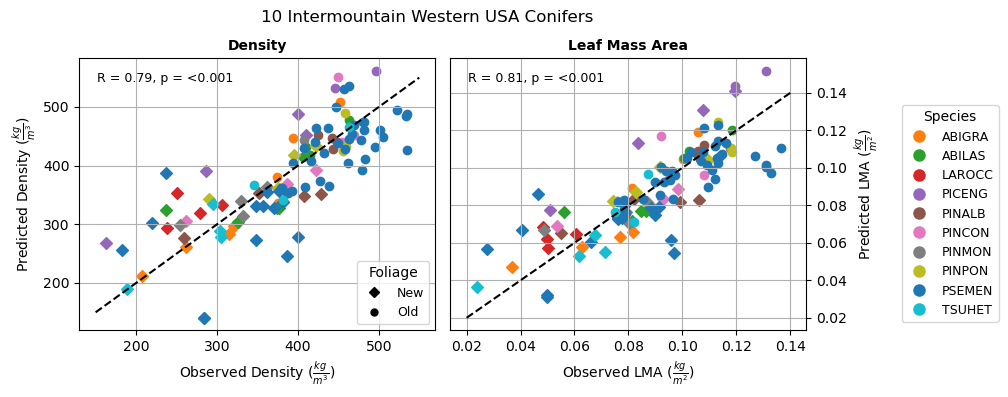

In [83]:
marker_styles = {'New': 'D', 'Old': 'o'}
species_list = sorted(df_con_all['species'].unique())

fig, ax = plt.subplots(1, 2, figsize=(8, 4))

for i, species in enumerate(species_list):
    for foliage, marker in marker_styles.items():
        subset = df_con_all[(df_con_all['species'] == species) &
                               (df_con_all['foliage'] == foliage)]
        
        ax[0].scatter(subset['Density'], subset['DensityHat'],
                      color = species_colors[species], marker=marker)
        ax[1].scatter(subset['LMA_kg_m'], subset['LMAHat'],
                      color = species_colors[species], marker=marker)

ax[0].plot([150, 550], [150, 550], 'k--')
ax[1].plot([0.02, 0.14], [0.02, 0.14], 'k--')

ax[0].set_xlabel(r"Observed Density ($\frac{kg}{m^3}$)", fontsize=10)
ax[0].set_ylabel(r"Predicted Density ($\frac{kg}{m^3}$)", fontsize=10)

ax[1].set_xlabel(r"Observed LMA ($\frac{kg}{m^2}$)", fontsize=10)
ax[1].set_ylabel(r"Predicted LMA ($\frac{kg}{m^2}$)", fontsize=10)
ax[1].yaxis.tick_right()
ax[1].yaxis.set_label_position("right")

for a in ax:
    a.grid(True)

# Correlations (same as before)
r_density, p_density = pearsonr(df_con_all['Density'], df_con_all['DensityHat'])
p_text_density = "<0.001" if p_density < 0.001 else f"{p_density:.3f}"
ax[0].text(0.05, 0.95, f"R = {r_density:.2f}, p = {p_text_density}",
           transform=ax[0].transAxes, fontsize=9, va='top')

r_lma, p_lma = pearsonr(df_con_all['LMA_kg_m'], df_con_all['LMAHat'])
p_text_lma = "<0.001" if p_lma < 0.001 else f"{p_lma:.3f}"
ax[1].text(0.05, 0.95, f"R = {r_lma:.2f}, p = {p_text_lma}",
           transform=ax[1].transAxes, fontsize=9, va='top')

# Legends
foliage_handles = [mlines.Line2D([], [], color='black', marker=marker, linestyle='None',
                                 markersize=5, label=foliage)
                   for foliage, marker in marker_styles.items()]
ax[0].legend(handles=foliage_handles, title="Foliage", loc='lower right', fontsize=9)

species_handles = [
    mlines.Line2D([], [], color=species_colors[species], marker='o',
                  linestyle='None', markersize=8, label=species)
    for species in species_list
]

ax[1].legend(handles=species_handles, title="Species",
             bbox_to_anchor=(1.25, 0.85), loc='upper left', fontsize=9)
ax[0].set_title("Density", fontsize=10, fontweight='bold')
ax[1].set_title("Leaf Mass Area", fontsize=10, fontweight='bold')

fig.suptitle(
    "10 Intermountain Western USA Conifers",
    fontsize=12,
    x=0.54
)

plt.tight_layout(rect=[0, 0, 1.25, 1.02])
plt.show()
fig.savefig("Figures/Density_LMA_Con.png", bbox_inches="tight")

In [84]:
def format_corr_p(p):
    """Format correlation p-values for figure labels."""
    if p < 0.001:
        return "<0.001"
    elif p < 0.01:
        return "<0.01"
    elif p < 0.05:
        return f"{p:.3f}"
    else:
        return f"{p:.2f}"

In [85]:
palette_scatter = {"New": "#2c7bb6", "Old": "#d7191c"}
palette = {
    "Measured - Old": "#fdae61",
    "Predicted - Old": "#d7191c",
    "Measured - New": "#abd9e9",
    "Predicted - New": "#2c7bb6"
}

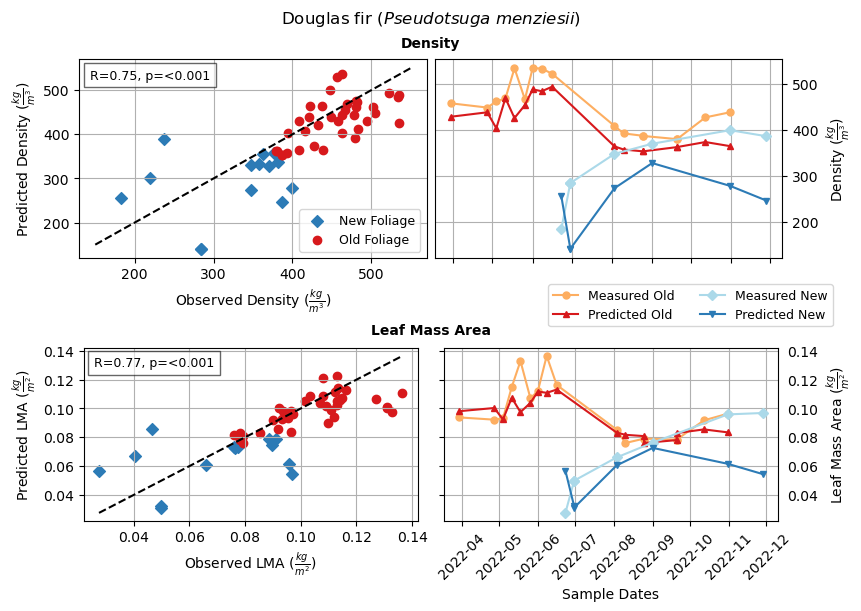

In [86]:
df_new = df_con_all[df_con_all['NewOldDV'] == 1].copy()
df_old = df_con_all[df_con_all['NewOldDV'] == 0].copy()

df_old = df_old[df_old.species == "PSEMEN"]
df_new = df_new[df_new.species == "PSEMEN"]

fig = plt.figure(figsize=(8.5, 6), constrained_layout=True)
fig.set_constrained_layout_pads(hspace=0.0)
subfigs = fig.subfigures(nrows=2, ncols=1)

subfig_density = subfigs[0]
subfig_density.suptitle("Density", fontsize=10, fontweight='bold')
ax_density = subfig_density.subplots(nrows=1, ncols=2)

ax00 = ax_density[0]

# correlations (measured vs predicted)
corr_new, p_new = stats.pearsonr(df_new['Density'], df_new['DensityHat'])
corr_old, p_old = stats.pearsonr(df_old['Density'], df_old['DensityHat'])

meas_all = np.concatenate([df_new['Density'], df_old['Density']])
pred_all = np.concatenate([df_new['DensityHat'], df_old['DensityHat']])
corr_combined, p_combined = stats.pearsonr(meas_all, pred_all)

# scatter
ax00.scatter(df_new['Density'], df_new['DensityHat'],
             color=palette_scatter['New'], marker=marker_styles['New'], label='New Foliage')
ax00.scatter(df_old['Density'], df_old['DensityHat'],
             color=palette_scatter['Old'], marker=marker_styles['Old'], label='Old Foliage')

# 1:1 line
ax00.plot([150, 550], [150, 550], 'k--')

ax00.text(0.03, 0.95,
          f"R={corr_combined:.2f}, p={format_corr_p(p_combined)}",
          transform=ax00.transAxes,
          fontsize=9, bbox=dict(facecolor='white', alpha=0.6),
          verticalalignment='top')

ax00.set_xlabel(r"Observed Density ($\frac{kg}{m^3}$)")
ax00.set_ylabel(r"Predicted Density ($\frac{kg}{m^3}$)")
ax00.legend(loc='lower right', fontsize=9)
ax00.grid(True)

ax01 = ax_density[1]

df_old_2022 = df_old[df_old['sample_dates'].dt.year == 2022].sort_values('sample_dates')
df_new_2022 = df_new[df_new['sample_dates'].dt.year == 2022].sort_values('sample_dates')

ax01.plot(df_old_2022['sample_dates'], df_old_2022['Density'],
          label='Measured Old', color=palette['Measured - Old'], marker='o', markersize=5)
ax01.plot(df_old_2022['sample_dates'], df_old_2022['DensityHat'],
          label='Predicted Old', color=palette['Predicted - Old'], marker='^', markersize=5)
ax01.plot(df_new_2022['sample_dates'], df_new_2022['Density'],
          label='Measured New', color=palette['Measured - New'], marker='D', markersize=5)
ax01.plot(df_new_2022['sample_dates'], df_new_2022['DensityHat'],
          label='Predicted New', color=palette['Predicted - New'], marker='v', markersize=5)

ax01.set_ylabel("Density ($\\frac{kg}{m^3}$)")
ax01.yaxis.set_label_position("right")
ax01.yaxis.tick_right()

ax01.tick_params(axis='x', labelbottom=False)
ax01.set_xlabel("")
ax01.grid(True)

subfig_lma = subfigs[1]
subfig_lma.suptitle("Leaf Mass Area", fontsize=10, fontweight='bold')
ax_lma = subfig_lma.subplots(nrows=1, ncols=2)

ax10 = ax_lma[0]

corr_new, p_new = stats.pearsonr(df_new['LMA_kg_m'], df_new['LMAHat'])
corr_old, p_old = stats.pearsonr(df_old['LMA_kg_m'], df_old['LMAHat'])

meas_all = np.concatenate([df_new['LMA_kg_m'], df_old['LMA_kg_m']])
pred_all = np.concatenate([df_new['LMAHat'], df_old['LMAHat']])
corr_combined, p_combined = stats.pearsonr(meas_all, pred_all)

ax10.scatter(df_new['LMA_kg_m'], df_new['LMAHat'],
             color=palette_scatter['New'], marker=marker_styles['New'])
ax10.scatter(df_old['LMA_kg_m'], df_old['LMAHat'],
             color=palette_scatter['Old'], marker=marker_styles['Old'])

lma_min = min(meas_all.min(), pred_all.min())
lma_max = max(meas_all.max(), pred_all.max())
ax10.plot([lma_min, lma_max], [lma_min, lma_max], 'k--')

ax10.text(0.03, 0.95,
          f"R={corr_combined:.2f}, p={format_corr_p(p_combined)}",
          transform=ax10.transAxes,
          fontsize=9, bbox=dict(facecolor='white', alpha=0.6),
          verticalalignment='top')

ax10.set_xlabel("Observed LMA ($\\frac{kg}{m^2}$)")
ax10.set_ylabel("Predicted LMA ($\\frac{kg}{m^2}$)")
ax10.grid(True)

ax11 = ax_lma[1]

ax11.plot(df_old_2022['sample_dates'], df_old_2022['LMA_kg_m'],
          color=palette['Measured - Old'], marker='o', markersize=5)
ax11.plot(df_old_2022['sample_dates'], df_old_2022['LMAHat'],
          color=palette['Predicted - Old'], marker='^', markersize=5)
ax11.plot(df_new_2022['sample_dates'], df_new_2022['LMA_kg_m'],
          color=palette['Measured - New'], marker='D', markersize=5)
ax11.plot(df_new_2022['sample_dates'], df_new_2022['LMAHat'],
          color=palette['Predicted - New'], marker='v', markersize=5)

handles01, labels01 = ax01.get_legend_handles_labels()
handles11, labels11 = ax11.get_legend_handles_labels()
handles = handles01 + handles11
labels = labels01 + labels11
fig.legend(handles, labels,
           loc='center right',
           bbox_to_anchor=(0.98, 0.50),
           fontsize=9,
           frameon=True,
           ncol=2)

ax11.set_xlabel("Sample Dates")
ax11.tick_params(axis='x', rotation=45)
ax11.yaxis.set_label_position("right")
ax11.tick_params(axis='y', labelright=True, labelleft=False)
ax11.set_ylabel("Leaf Mass Area ($\\frac{kg}{m^2}$)")
ax11.grid(True)

fig.align_ylabels([ax00, ax10])
fig.align_ylabels([ax01, ax11])

fig.suptitle("Douglas fir ($\\mathit{Pseudotsuga}$ $\\mathit{menziesii}$)", fontsize=12)
plt.show()

fig.savefig("Figures/DensityLMA_PSME.png", bbox_inches="tight")

## Exploratory LFMC 

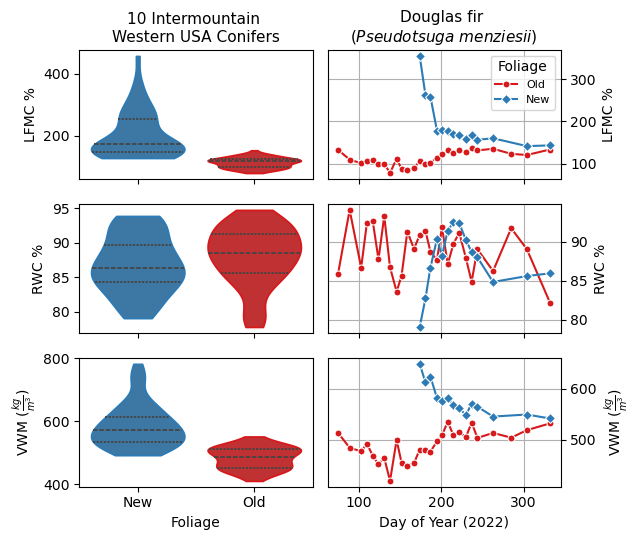

In [87]:
palette_violin = {"New": "#2c7bb6", "Old": "#d7191c"}
palette_line = {'New': '#2c7bb6', 'Old': '#d7191c'}
markers = {'New': 'D', 'Old': 'o'}

violin_vars = [
    ('LFMC', "LFMC %"),
    ('RWC', "RWC %"),
    ('VWM', "VWM ($\\frac{kg}{m^3}$)")
]

line_vars = [
    ('LFMC', "LFMC %"),
    ('RWC', "RWC %"),
    ('VWM', "VWM ($\\frac{kg}{m^3}$)")
]

# Filter 2022 data for time series
df_2022_old = df_2022[df_2022['foliage'] == 'Old']
df_2022_new = df_2022[df_2022['foliage'] == 'New']

#  CREATE COMBINED FIGURE
fig, axes = plt.subplots(
    3, 2, figsize=(6.5, 5.5),
    sharex='col'
)

#  LEFT COLUMN: VIOLIN PLOTS
for i, (col, label) in enumerate(violin_vars):

    ax = axes[i, 0]

    sns.violinplot(
        data=df_plot,
        x="foliage",
        y=col,
        hue="foliage",
        palette=palette_violin,
        fill=True,
        alpha=0.5,
        linewidth=1.3,
        legend=False,
        ax=ax,
        cut=0,
        inner="quartile"
    )

    # Style violins
    foliage_vals = df_plot["foliage"].unique()
    for j, patch in enumerate(ax.collections):
        hue_val = foliage_vals[j % len(foliage_vals)]
        patch.set_edgecolor(palette_violin[hue_val])
        patch.set_alpha(1)

    # Axis labels
    ax.set_ylabel(label, fontsize=10)
    ax.yaxis.set_label_position("left")
    ax.tick_params(axis="y", labelright=False, labelleft=True)

    if i < 2:
        ax.set_xlabel("")
        ax.tick_params(axis="x", labelbottom=False)
    else:
        ax.set_xlabel("Foliage")

# Column title
axes[0, 0].set_title("10 Intermountain \nWestern USA Conifers", fontsize=11)

#  RIGHT COLUMN: TIME SERIES
for i, (var, ylab) in enumerate(line_vars):

    ax = axes[i, 1]

    sns.lineplot(
        data=df_2022,
        x='doy', y=var,
        hue='foliage', style='foliage',
        markers=markers, dashes=False,
        palette=palette_line, ax=ax, markersize=5
    )

    ax.set_ylabel(ylab)
    ax.grid(True)

    ax.yaxis.set_label_position("right")
    ax.yaxis.tick_right()

    if i < 2:
        ax.set_xlabel("")
        ax.tick_params(axis='x', labelbottom=False)
    else:
        ax.set_xlabel("Day of Year (2022)")

    ax.legend_.remove()

# Legend for right column
handles, labels = axes[0, 1].get_legend_handles_labels()
axes[0, 1].legend(handles, labels, title='Foliage',
                  loc='upper right', fontsize=8, frameon=True)

# Column title
axes[0, 1].set_title("Douglas fir \n($\\mathit{Pseudotsuga}$ $\\mathit{menziesii}$)", fontsize=11)

plt.tight_layout()
plt.show()

fig.savefig("Figures/combined_violin_timeseries_lfmc.png", bbox_inches="tight")

In [88]:
df_plot = df_con_concat[df_con_concat["foliage"].isin(["New", "Old"])].copy()
fraction_vars = ["nsc", "cf", "ndf"]
for col in fraction_vars:
    df_plot[col + "_pct"] = df_plot[col] * 100
    
variables = ["LFMC", "SAV_m", "RWC", "VWM", "k"]

for col in variables:
    print(f"\n=== {col} ===")
    stats = df_plot.groupby("foliage")[col].agg(
        Q1=lambda x: x.quantile(0.25),
        Median="median",
        Q3=lambda x: x.quantile(0.75),
        Mean="mean",
        Std="std"
    )
    print(stats)


=== LFMC ===
                 Q1      Median          Q3        Mean        Std
foliage                                                           
New      146.382914  172.413606  253.796957  202.763547  75.095299
Old       99.196183  115.742175  122.892652  112.117255  16.286657

=== SAV_m ===
                  Q1       Median           Q3         Mean         Std
foliage                                                                
New      4118.171108  4291.447701  4951.549832  4570.521908  832.684329
Old      4009.893662  4345.836633  4659.248330  4348.090589  460.136902

=== RWC ===
                Q1     Median         Q3       Mean       Std
foliage                                                      
New      84.280644  86.425618  89.685348  86.861617  4.154859
Old      85.644472  88.540242  91.311200  88.114945  4.245918

=== VWM ===
                 Q1      Median          Q3        Mean        Std
foliage                                                           
New    

### Create Table 8 from manuscript

In [89]:
df_con_all.groupby([df_con_all.species,df_con_all.foliage])[['LFMC','RWC','VWM','k']].mean().round(2)

LFMC    RWC     VWM       k
species foliage                               
ABIGRA  New      218.10  90.23  565.77  630.62
        Old      122.33  89.79  482.31  538.13
ABILAS  New      171.85  88.59  530.22  599.37
        Old      110.81  86.45  461.66  534.29
LAROCC  New      220.88  84.77  574.63  679.34
PICENG  New      240.78  88.41  622.52  708.14
        Old      110.77  88.39  514.65  583.76
PINALB  New      175.49  85.86  587.44  687.50
        Old      119.37  84.45  518.22  616.69
PINCON  New      203.01  83.68  650.86  776.03
        Old      111.12  79.28  505.62  639.13
PINMON  New      200.36  85.56  608.69  712.60
        Old      125.00  78.60  510.18  649.08
PINPON  New      184.15  82.05  638.26  779.25
        Old      120.28  80.95  544.67  675.60
PSEMEN  New      198.68  87.91  568.71  652.04
        Old      108.17  89.99  474.50  528.85
TSUHET  New      224.60  88.12  560.35  642.97
        Old      128.64  88.87  491.95  554.90

## Plot LFMC predictions

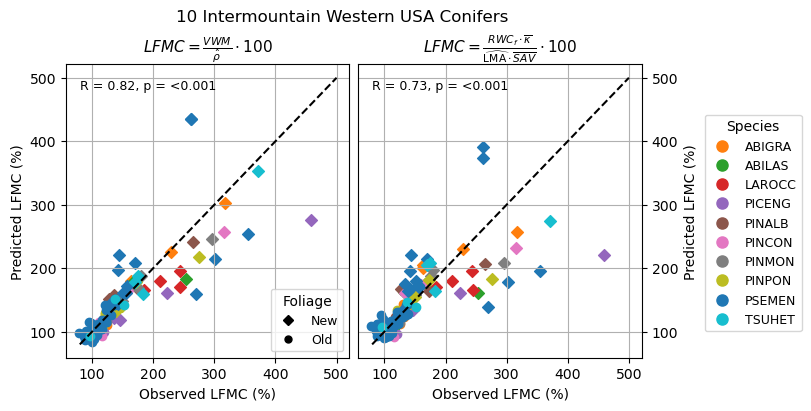

In [90]:
marker_styles = {'New': 'D', 'Old': 'o'}

fig, ax = plt.subplots(1, 2, figsize=(8, 4), constrained_layout=True)

# --- Scatter plots ---
for i, species in enumerate(species_list):
    for foliage, marker in marker_styles.items():
        subset = df_con_all[
            (df_con_all['species'] == species) &
            (df_con_all['foliage'] == foliage)
        ]

        # FLIPPED AXES: observed on x, predicted on y
        ax[1].scatter(
            subset['LFMC'], subset['LFMC2025'],
            color=species_colors[species], marker=marker
        )
        ax[0].scatter(
            subset['LFMC'], subset['LFMCvw'],
            color=species_colors[species], marker=marker
        )

# --- 1:1 reference lines ---
ax[0].plot([80, 500], [80, 500], 'k--')
ax[1].plot([80, 500], [80, 500], 'k--')

# --- Axis labels ---
for a in ax:
    a.set_xlabel("Observed LFMC (%)", fontsize=10)
    a.set_ylabel("Predicted LFMC (%)", fontsize=10)
    a.grid(True)

# Right-hand y-axis ticks for subplot 2
ax[1].yaxis.tick_right()
ax[1].yaxis.set_label_position("right")

# --- Correlations ---
r_lfmc25, p_lfmc25 = pearsonr(df_con_all['LFMC'], df_con_all['LFMC2025'])
p_text_lfmc25 = "<0.001" if p_lfmc25 < 0.001 else f"{p_lfmc25:.3f}"
ax[1].text(0.05, 0.95, f"R = {r_lfmc25:.2f}, p = {p_text_lfmc25}",
           transform=ax[1].transAxes, fontsize=9, va='top')

valid = df_con_all[['LFMC', 'LFMCvw']].dropna()
r_lfmcvw, p_lfmcvw = pearsonr(valid['LFMC'], valid['LFMCvw'])
p_text_lfmcvw = "<0.001" if p_lfmcvw < 0.001 else f"{p_lfmcvw:.3f}"
ax[0].text(0.05, 0.95, f"R = {r_lfmcvw:.2f}, p = {p_text_lfmcvw}",
           transform=ax[0].transAxes, fontsize=9, va='top')

# --- Legends ---
foliage_handles = [
    mlines.Line2D([], [], color='black', marker=marker, linestyle='None',
                  markersize=5, label=foliage)
    for foliage, marker in marker_styles.items()
]
ax[0].legend(handles=foliage_handles, title="Foliage",
             loc='lower right', fontsize=9)

species_handles = [
    mlines.Line2D([], [], color=species_colors[species], marker='o',
                  linestyle='None', markersize=8, label=species)
    for species in species_list
]
ax[1].legend(handles=species_handles, title="Species",
             bbox_to_anchor=(1.20, 0.85), loc='upper left', fontsize=9)

ax[0].set_title(
    r"$LFMC = \frac{VWM}{\hat{\rho}} \cdot 100$",
    fontsize=11, 
    fontweight='bold'
)

ax[1].set_title(
    r"$LFMC = \frac{RWC_f \cdot \overline{\kappa}}{\widehat{\mathrm{LMA}} \cdot \overline{SAV}} \cdot 100$",
    fontsize=11,
    fontweight='bold'
)

# --- Figure title ---
fig.suptitle("10 Intermountain Western USA Conifers", fontsize=12, x=0.42)

# --- Save ---
plt.show()
fig.savefig("Figures/LFMC_Con.png", bbox_inches="tight")

In [91]:
df_new = df_con_all[df_con_all['NewOldDV'] == 1].copy()
df_old = df_con_all[df_con_all['NewOldDV'] == 0].copy()

df_old = df_old[df_old.species == "PSEMEN"]
df_new = df_new[df_new.species == "PSEMEN"]

In [92]:
from scipy import stats
# Combined arrays for correlations
lfmc_combined = np.concatenate([df_new['LFMC'], df_old['LFMC']])

pred_combined_2025 = np.concatenate([df_new['LFMC2025'], df_old['LFMC2025']])
pred_combined_vw   = np.concatenate([df_new['LFMCvw'],   df_old['LFMCvw']])

corr_combined_2025, p_combined_2025 = stats.pearsonr(lfmc_combined, pred_combined_2025)
corr_combined_vw,   p_combined_vw   = stats.pearsonr(lfmc_combined, pred_combined_vw)

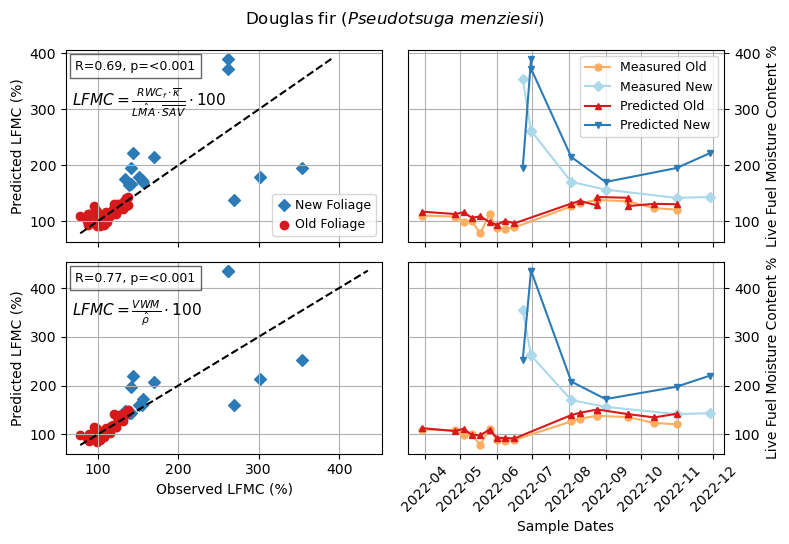

In [93]:
palette_scatter = {'New': '#2c7bb6', 'Old': '#d7191c'}
marker_styles = {'New': 'D', 'Old': 'o'}

fig, ax = plt.subplots(2, 2, figsize=(8, 5.5), sharex='col')

def format_corr_p(p):
    return "<0.001" if p < 0.001 else f"{p:.3f}"

ax[0,0].scatter(df_new['LFMC'], df_new['LFMC2025'],
                color=palette_scatter['New'], marker=marker_styles['New'], label='New Foliage')
ax[0,0].scatter(df_old['LFMC'], df_old['LFMC2025'],
                color=palette_scatter['Old'], marker=marker_styles['Old'], label='Old Foliage')

# Legend for foliage types
handles_fol, labels_fol = ax[0,0].get_legend_handles_labels()
foliage_leg = ax[0,0].legend(handles_fol, labels_fol,
                             loc='lower right',
                             fontsize=9, frameon=True,
                             handlelength=1.0, handletextpad=0.4)
ax[0,0].add_artist(foliage_leg)

# 1:1 line
lfmc_min = min(lfmc_combined.min(), pred_combined_2025.min())
lfmc_max = max(lfmc_combined.max(), pred_combined_2025.max())
ax[0,0].plot([lfmc_min, lfmc_max], [lfmc_min, lfmc_max], 'k--')

# correlation text
ax[0,0].text(0.03, 0.95,
             f"R={corr_combined_2025:.2f}, p={format_corr_p(p_combined_2025)}",
             fontsize=9, bbox=dict(facecolor='white', alpha=0.6),
             transform=ax[0,0].transAxes,
             verticalalignment='top', horizontalalignment='left')

ax[0,0].set_xlabel("")
ax[0,0].set_ylabel("Predicted LFMC (%)")
ax[0,0].grid(True)

# Equation legend
equation2025 = r"$LFMC = \frac{RWC_f \cdot \overline{\kappa}}{\hat{LMA} \cdot \overline{SAV}} \cdot 100$"
eq_handle0 = Patch(facecolor='none', edgecolor='none', label=equation2025)
ax[0,0].legend([eq_handle0], [equation2025],
               loc='upper left', bbox_to_anchor=(-0.16, 0.88), fontsize=11, frameon=False)

df_old_2022 = df_old[df_old['sample_dates'].dt.year == 2022].sort_values('sample_dates')
df_new_2022 = df_new[df_new['sample_dates'].dt.year == 2022].sort_values('sample_dates')

ax[0,1].plot(df_old_2022['sample_dates'], df_old_2022['LFMC'],
             label='Measured Old', color='#fdae61', marker='o', markersize=5)
ax[0,1].plot(df_new_2022['sample_dates'], df_new_2022['LFMC'],
             label='Measured New', color='#abd9e9', marker='D', markersize=5)
ax[0,1].plot(df_old_2022['sample_dates'], df_old_2022['LFMC2025'],
             label='Predicted Old', color='#d7191c', marker='^', markersize=5)
ax[0,1].plot(df_new_2022['sample_dates'], df_new_2022['LFMC2025'],
             label='Predicted New', color='#2c7bb6', marker='v', markersize=5)

ax[0,1].set_ylabel("Live Fuel Moisture Content %")
ax[0,1].grid(True)
ax[0,1].set_xlabel("")
ax[0,1].tick_params(axis='x', labelbottom=False)
ax[0,1].yaxis.set_label_position("right")
ax[0,1].yaxis.tick_right()

handles_ts, labels_ts = ax[0,1].get_legend_handles_labels()
ax[0,1].legend(handles_ts, labels_ts, loc='upper right', fontsize=9)

ax[1,0].scatter(df_new['LFMC'], df_new['LFMCvw'],
                color=palette_scatter['New'], marker=marker_styles['New'])
ax[1,0].scatter(df_old['LFMC'], df_old['LFMCvw'],
                color=palette_scatter['Old'], marker=marker_styles['Old'])

lfmc_min_vw = min(lfmc_combined.min(), pred_combined_vw.min())
lfmc_max_vw = max(lfmc_combined.max(), pred_combined_vw.max())
ax[1,0].plot([lfmc_min_vw, lfmc_max_vw], [lfmc_min_vw, lfmc_max_vw], 'k--')

ax[1,0].text(0.03, 0.95,
             f"R={corr_combined_vw:.2f}, p={format_corr_p(p_combined_vw)}",
             fontsize=9, bbox=dict(facecolor='white', alpha=0.6),
             transform=ax[1,0].transAxes,
             verticalalignment='top', horizontalalignment='left')

ax[1,0].set_xlabel("Observed LFMC (%)")
ax[1,0].set_ylabel("Predicted LFMC (%)")
ax[1,0].grid(True)

equationvw = r"$LFMC = \frac{VWM}{\hat{\rho}} \cdot 100$"
eq_handle1 = Patch(facecolor='none', edgecolor='none', label=equationvw)
ax[1,0].legend([eq_handle1], [equationvw],
               loc='upper left', bbox_to_anchor=(-0.16, 0.88), fontsize=11, frameon=False)

ax[1,1].plot(df_old_2022['sample_dates'], df_old_2022['LFMC'],
             color='#fdae61', marker='o', markersize=5)
ax[1,1].plot(df_new_2022['sample_dates'], df_new_2022['LFMC'],
             color='#abd9e9', marker='D', markersize=5)
ax[1,1].plot(df_old_2022['sample_dates'], df_old_2022['LFMCvw'],
             color='#d7191c', marker='^', markersize=5)
ax[1,1].plot(df_new_2022['sample_dates'], df_new_2022['LFMCvw'],
             color='#2c7bb6', marker='v', markersize=5)

ax[1,1].set_xlabel("Sample Dates")
ax[1,1].tick_params(axis='x', rotation=45)
ax[1,1].set_ylabel("Live Fuel Moisture Content %")
ax[1,1].grid(True)
ax[1,1].yaxis.set_label_position("right")
ax[1,1].yaxis.tick_right()

fig.suptitle("Douglas fir ($\\mathit{Pseudotsuga}$ $\\mathit{menziesii}$)", fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()

fig.savefig("Figures/LFMC_PSME.png", bbox_inches="tight")

### Sample Sizes

In [94]:
variables = ["LMA_kg_m", "Density", "LMAHat", "DensityHat", "LFMC", "LFMC2025", "LFMCvw"]

df_con_all[variables].count()

LMA_kg_m      110
Density       110
LMAHat        110
DensityHat    110
LFMC          110
LFMC2025      110
LFMCvw        110
dtype: int64

In [95]:
variables = ["LMA_kg_m", "Density", "LMAHat", "DensityHat", "LFMC", "LFMC2025", "LFMCvw"]

df_new[variables].count()

LMA_kg_m      14
Density       14
LMAHat        14
DensityHat    14
LFMC          14
LFMC2025      14
LFMCvw        14
dtype: int64

In [96]:
variables = ["LMA_kg_m", "Density", "LMAHat", "DensityHat", "LFMC", "LFMC2025", "LFMCvw"]

df_old[variables].count()

LMA_kg_m      37
Density       37
LMAHat        37
DensityHat    37
LFMC          37
LFMC2025      37
LFMCvw        37
dtype: int64